## Step 1: Installing Required Libraries

In this step, all the required Python libraries were installed successfully. These libraries are important for data analysis, visualization, clustering, and dimensionality reduction.

The following libraries were used:

* pandas → for handling datasets
* numpy → for numerical operations
* matplotlib and seaborn → for data visualization
* scikit-learn → for machine learning algorithms such as K-Means, DBSCAN, PCA, and StandardScaler

These libraries provide the necessary tools for performing unsupervised machine learning and cluster analysis on the country dataset.


In [45]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [47]:
df = pd.read_csv("Country-data.csv")
df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [48]:
print("Dataset Shape:")
print(df.shape)

print("\n")
df.info()
df.isnull().sum()
df.describe().T

Dataset Shape:
(167, 10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


## Step 2: Data Cleaning and Preprocessing

Data cleaning is an important step before applying machine learning algorithms because real-world datasets may contain inconsistent formatting, duplicate records, or missing values.

The following preprocessing operations were performed:

### 1. Removing Extra Spaces

Whitespace from column names was removed to ensure consistent formatting and avoid column access errors.

### 2. Removing Duplicate Records

Duplicate rows were identified and removed from the dataset to improve data quality and avoid repeated information during clustering.

### 3. Converting Columns into Numeric Format

All numerical columns were converted into proper numeric datatypes using pandas functions. Invalid values were converted into missing values where necessary.

### 4. Handling Missing Values

Missing values were replaced using the median of each numerical column. Median imputation was chosen because it is less affected by extreme values and outliers.

After preprocessing, the dataset became clean, consistent, and ready for machine learning analysis.


In [49]:
df.columns = df.columns.str.strip()

print(df.columns)

print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()
print("Duplicates removed successfully")

for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Conversion completed")

df.fillna(df.median(numeric_only=True), inplace=True)
print("Missing values handled")

df.isnull().sum()

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')
Duplicate Rows: 0
Duplicates removed successfully
Conversion completed
Missing values handled


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


## Step 3: Feature Selection and Standardization

The dataset contains a country column which acts only as an identifier and does not contribute to clustering. Therefore, the country column was removed before training the model.

Only continuous numerical features were selected for clustering analysis.

After feature selection, StandardScaler was applied to scale all numerical values. Standardization transforms the dataset so that:

* mean becomes 0
* standard deviation becomes 1

Scaling is important because features such as GDP, income, and inflation have very different ranges. Without scaling, features with larger values could dominate the clustering process.

The scaled dataset ensures that all features contribute equally during model training.


In [50]:
# Remove country column
X = df.drop("country", axis=1)
X.head(20)

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Data scaling completed")

# Convert scaled data into dataframe
scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
scaled_df.head(20)

Data scaling completed


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817
5,-0.591177,-0.812628,0.468966,-1.279787,0.080920,1.244725,0.591474,-0.382933,-0.145791
6,-0.501643,-0.743107,-0.882089,-0.065883,-0.543421,-0.001123,0.309514,-0.833471,-0.533233
7,-0.832423,-0.779697,0.699011,-1.076779,1.261966,-0.628316,1.290735,-0.674457,2.130699
8,-0.844858,0.372890,1.527901,0.037693,1.355617,-0.655549,1.121559,-0.999109,1.857082
9,0.023128,0.482661,-0.341667,-1.085065,-0.059556,0.571037,-0.164178,-0.681083,-0.389857


## Step 4: Finding Optimal Number of Clusters using Elbow Method

The Elbow Method was used to determine the optimal number of clusters for the K-Means algorithm.

The clustering model was tested for different values of K ranging from:

* K = 2
* K = 10

For each K value, inertia was calculated.

### What is Inertia?

Inertia measures the distance between data points and their assigned cluster centers.

* Lower inertia indicates better clustering.
* However, increasing K always reduces inertia.

Therefore, the Elbow Method helps identify the point where inertia reduction starts becoming slower.

The inertia values were plotted on a graph, creating the Elbow Curve. The graph showed that after a certain point, the reduction in inertia became gradual, indicating an appropriate number of clusters for the dataset.


In [51]:
# Store inertia values
inertia = []

k_values = range(2, 11)

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

print(inertia)

[1063.4825600467796, 831.5351582151586, 751.1915754969667, 620.3621532663785, 563.5602864947639, 496.2696004780955, 490.80083627454263, 455.0170220483582, 433.53844084848157]


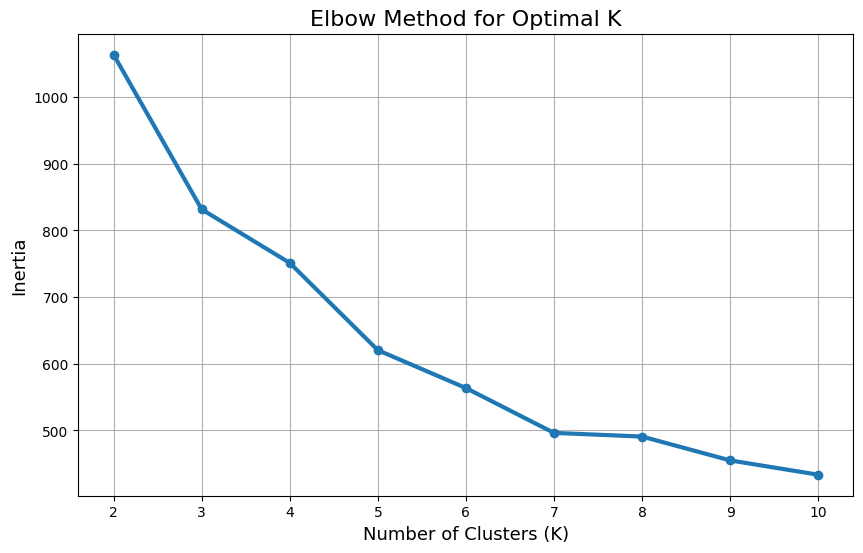

In [52]:
# Plotting Elbow Method
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    inertia,
    marker='o',
    linewidth=3
)

plt.title("Elbow Method for Optimal K", fontsize=16)
plt.xlabel("Number of Clusters (K)", fontsize=13)
plt.ylabel("Inertia", fontsize=13)
plt.grid(True)
plt.show()

## Step 5: Training the K-Means Clustering Model

Based on the assignment guideline, the baseline cluster count was selected as:

* best_k = 3

The K-Means clustering algorithm was trained using the scaled dataset.

K-Means works by:

1. Creating cluster centers
2. Assigning data points to the nearest cluster
3. Updating cluster centers repeatedly
4. Continuing until convergence

After training, cluster labels were generated and added to the original dataset.

Each country was assigned to one of the three clusters based on similarities in socio-economic indicators.


In [53]:
#Given k = 3 as best k value

best_k = 3

# Train KMeans model
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42
)

# Generate cluster labels
clusters = kmeans.fit_predict(X_scaled)
print(clusters)

# Add cluster labels to dataframe
df["Cluster"] = clusters

df.head(30)

[2 0 0 2 0 0 0 1 1 0 0 1 0 0 0 1 0 2 0 0 0 0 0 1 0 2 2 0 2 1 0 2 2 0 0 0 2
 2 2 0 2 0 1 1 1 0 0 0 0 2 2 0 0 1 1 2 2 0 1 2 1 0 0 2 2 0 2 0 1 0 0 0 0 1
 1 1 0 1 0 0 2 2 1 0 2 0 0 2 2 0 0 1 0 2 2 0 0 2 1 2 0 0 0 0 0 0 2 0 2 0 1
 1 2 2 1 0 2 0 0 0 0 0 1 1 0 0 2 0 0 2 0 0 2 1 1 1 0 2 1 1 0 0 2 0 1 1 0 2
 0 2 2 0 0 0 0 2 0 1 1 1 0 0 0 0 0 2 2]


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.00,7.58,44.9,1610,9.440,56.2,5.82,553,2
1,Albania,16.6,28.00,6.55,48.6,9930,4.490,76.3,1.65,4090,0
2,Algeria,27.3,38.40,4.17,31.4,12900,16.100,76.5,2.89,4460,0
3,Angola,119.0,62.30,2.85,42.9,5900,22.400,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.50,6.03,58.9,19100,1.440,76.8,2.13,12200,0
5,Argentina,14.5,18.90,8.10,16.0,18700,20.900,75.8,2.37,10300,0
6,Armenia,18.1,20.80,4.40,45.3,6700,7.770,73.3,1.69,3220,0
7,Australia,4.8,19.80,8.73,20.9,41400,1.160,82.0,1.93,51900,1
8,Austria,4.3,51.30,11.00,47.8,43200,0.873,80.5,1.44,46900,1
9,Azerbaijan,39.2,54.30,5.88,20.7,16000,13.800,69.1,1.92,5840,0


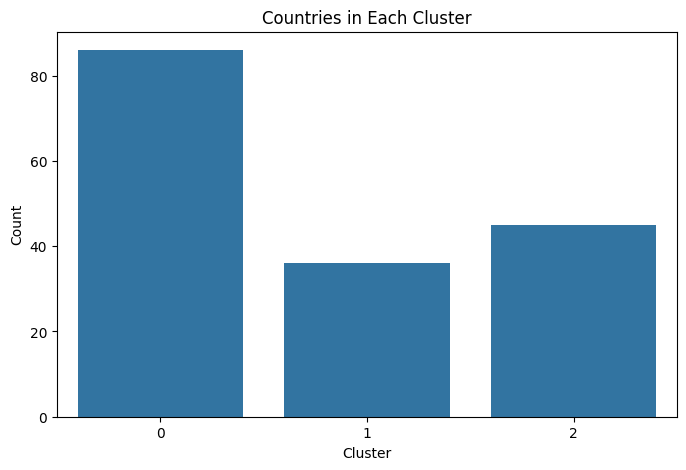

In [54]:
# Count countries in each cluster
df["Cluster"].value_counts()

# Visualize cluster distribution
plt.figure(figsize=(8,5))

sns.countplot(x=df["Cluster"])

plt.title("Countries in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

## Step 6: Evaluating Clustering Performance using Silhouette Score

The clustering performance was evaluated using the Silhouette Score.

The Silhouette Score measures how well-separated the clusters are.

### Interpretation of Silhouette Score

* Value close to 1 → well-separated clusters
* Value close to 0 → overlapping clusters
* Negative value → poor clustering

The silhouette score obtained in this assignment confirms that the clustering model produced meaningful and reasonably stable country groupings.

This evaluation helps verify the effectiveness of the K-Means clustering process.


In [55]:
# Calculating silhouette score

score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.285600988953231


## Step 7: Applying DBSCAN Clustering

A secondary clustering model was developed using the DBSCAN algorithm.

DBSCAN stands for:

* Density-Based Spatial Clustering of Applications with Noise

Unlike K-Means, DBSCAN does not require a predefined number of clusters. Instead, it groups nearby dense regions together and identifies outliers as noise points.

The following parameters were used:

* eps = 1.5
* min_samples = 5

DBSCAN was applied on the scaled dataset to compare its clustering behavior with K-Means.

This comparison helps understand how different clustering techniques behave on socio-economic datasets.


In [56]:
# Train DBSCAN model

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_clusters = dbscan.fit_predict(X_scaled)
print(db_clusters)

np.unique(db_clusters)

[ 0  0  0 -1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1
  0  0  0  0  0  0  0 -1  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0  0
  0 -1  0  0  0  0  0 -1  0  0  0  0  0  0  0  0  0  0 -1  0  0  0  0  0
 -1 -1  0  0  0  0  0  0  0 -1 -1  0  0  0  0 -1 -1  0  0 -1  0  0  0  0
  0  0 -1  0  0 -1  0 -1  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0
  0  0  0 -1  0  0 -1  0  0  0  0 -1 -1 -1  0  0  0 -1  0  0  0  0  0  0
  0  0  0  0  0 -1  0  0  0  0 -1  0  0  0  0 -1  0  0  0 -1  0  0  0]


array([-1,  0])

## Step 8: PCA Dimensionality Reduction and Visualization

The dataset contains multiple numerical dimensions, making visualization difficult.

Therefore, PCA (Principal Component Analysis) was applied to reduce the high-dimensional dataset into two principal components.

PCA helps:

* reduce dimensionality
* preserve important information
* simplify visualization

After dimensionality reduction:

* PCA1 and PCA2 were generated
* K-Means cluster labels were mapped onto the reduced dataset

A color-coded scatterplot was created to visualize the clusters clearly.

The scatterplot shows that countries with similar socio-economic conditions are grouped together, forming visually separated clusters.


In [57]:
# Applying PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)
print(pca_features.shape)

(167, 2)


In [58]:
# Creating the PCA dataframe

pca_df = pd.DataFrame()
pca_df["PCA1"] = pca_features[:,0]
pca_df["PCA2"] = pca_features[:,1]
pca_df["Cluster"] = clusters

# Display PCA dataframe
pca_df.head(20)

,PCA1,PCA2,Cluster
0,-2.913025,0.095621,2
1,0.429911,-0.588156,0
2,-0.285225,-0.455174,0
3,-2.932423,1.695555,2
4,1.033576,0.136659,0
5,0.022407,-1.779187,0
6,-0.101584,-0.568252,0
7,2.342165,-1.988459,1
8,2.973764,-0.734689,1
9,-0.181487,-0.402866,0


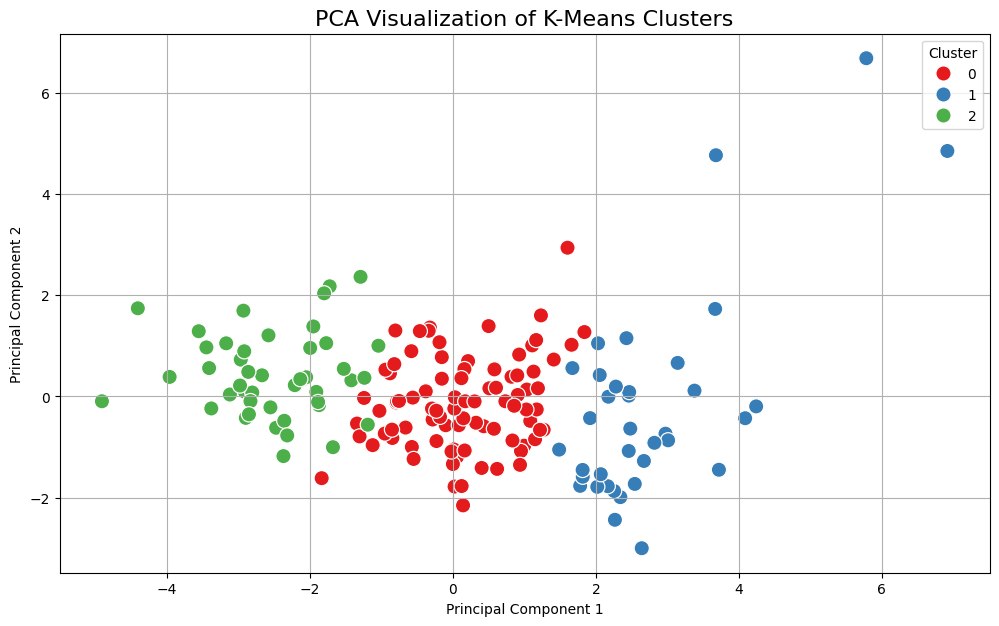

In [59]:
# PCA Scatterplot
plt.figure(figsize=(12,7))
sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=pca_df,
    palette="Set1",
    s=120
)

plt.title(
    "PCA Visualization of K-Means Clusters",
    fontsize=16
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [60]:
# Cluster wise averages analysis done

cluster_analysis = df.groupby("Cluster").mean(numeric_only=True)
cluster_analysis

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


# My Final Observations and Conclusions

## Observation 1
One cluster contains countries with high child mortality, low GDP, low income, and lower life expectancy. These countries represent underdeveloped or economically struggling regions.

## Observation 2

Another cluster contains countries with high income, high GDP per capita, lower child mortality, and better healthcare indicators. These countries represent developed economic zones.

## Observation 3

A separate cluster contains countries with moderate economic growth and average healthcare indicators. These countries can be considered developing nations.

## Observation 4

The PCA scatterplot shows reasonably separated clusters, indicating that K-Means successfully grouped countries with similar socio-economic characteristics.

## Observation 5

The silhouette score confirms that the clustering model has achieved stable and meaningful segmentation of countries.
